# Game Theory Applied to Trading

Apply Nash equilibrium analysis, auction theory, and repeated-game reasoning to multi-agent trading environments, with direct application to IMC Prosperity 4.

**Theory references:** [Nash Equilibrium](../theory/05_game_theory/nash_equilibrium.md) | [Auction Theory](../theory/05_game_theory/auction_theory.md) | [Repeated Games](../theory/05_game_theory/repeated_games.md)

In [1]:
from __future__ import annotations

import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

mpl.rcParams.update({
    'font.family': 'serif', 'font.size': 11, 'axes.labelsize': 11,
    'axes.titlesize': 12, 'axes.titleweight': 'normal',
    'legend.fontsize': 10, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
COLORS = ['#534AB7', '#0F6E56', '#D85A30', '#185FA5', '#993556', '#3B6D11', '#BA7517']


def save_fig(fig: plt.Figure, topic: str, name: str) -> None:
    """Save figure to plots/<topic>/ as both PDF and PNG."""
    folder = os.path.join('..', 'plots', topic)
    os.makedirs(folder, exist_ok=True)
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(folder, f'{name}.{ext}'))
    print(f'Saved \u2192 plots/{topic}/{name}.[pdf|png]')

## Section 1 — Nash Equilibria

A Nash equilibrium is a profile where no player gains from a unilateral deviation, and finite games always have at least one mixed-strategy equilibrium. The toolkit is developed in [nash_equilibrium.md](../theory/05_game_theory/nash_equilibrium.md).


In [2]:
def find_pure_nash(payoff_A: np.ndarray, payoff_B: np.ndarray) -> list[tuple[int, int]]:
    """Find all pure-strategy Nash equilibria in a two-player normal-form game.

    Parameters
    ----------
    payoff_A : np.ndarray
        (m, n) array of Player A's (row player's) payoffs.
    payoff_B : np.ndarray
        (m, n) array of Player B's (column player's) payoffs.

    Returns
    -------
    list[tuple[int, int]]
        (row, col) index pairs that are pure-strategy Nash equilibria.
    """
    m, n = payoff_A.shape
    equilibria: list[tuple[int, int]] = []
    for i in range(m):
        for j in range(n):
            if payoff_A[i, j] >= np.max(payoff_A[:, j]):
                if payoff_B[i, j] >= np.max(payoff_B[i, :]):
                    equilibria.append((i, j))
    return equilibria

In [3]:
games = [
    {
        'title': "Prisoner's Dilemma",
        'strategies': ['Cooperate', 'Defect'],
        'A': np.array([[3, 0], [5, 1]]),
        'B': np.array([[3, 5], [0, 1]]),
    },
    {
        'title': 'Stag Hunt (Coordination)',
        'strategies': ['Stag', 'Hare'],
        'A': np.array([[4, 0], [3, 2]]),
        'B': np.array([[4, 3], [0, 2]]),
    },
    {
        'title': 'Market Entry',
        'strategies': ['Enter', 'Stay Out'],
        'A': np.array([[-1, 2], [0, 0]]),
        'B': np.array([[-1, 0], [2, 0]]),
    },
]

for game in games:
    ne = find_pure_nash(game['A'], game['B'])
    strats = game['strategies']
    print(f"=== {game['title']} ===")
    print("  Payoff matrix  (row = Player A, col = Player B):")
    header = ''.ljust(14) + ''.join(s.center(14) for s in strats)
    print(f"  {header}")
    m, n = game['A'].shape
    for i in range(m):
        row_str = strats[i].ljust(14)
        for j in range(n):
            cell = f"({game['A'][i, j]:2d}, {game['B'][i, j]:2d})"
            row_str += cell.center(14)
        print(f"  {row_str}")
    if ne:
        ne_labels = [f"({strats[r]}, {strats[c]})" for r, c in ne]
        print(f"  Pure NE: {', '.join(ne_labels)}")
    else:
        print("  Pure NE: none (only mixed-strategy equilibria exist)")
    print()

=== Prisoner's Dilemma ===
  Payoff matrix  (row = Player A, col = Player B):
                  Cooperate       Defect    
  Cooperate        ( 3,  3)      ( 0,  5)   
  Defect           ( 5,  0)      ( 1,  1)   
  Pure NE: (Defect, Defect)

=== Stag Hunt (Coordination) ===
  Payoff matrix  (row = Player A, col = Player B):
                     Stag          Hare     
  Stag             ( 4,  4)      ( 0,  3)   
  Hare             ( 3,  0)      ( 2,  2)   
  Pure NE: (Stag, Stag), (Hare, Hare)

=== Market Entry ===
  Payoff matrix  (row = Player A, col = Player B):
                    Enter        Stay Out   
  Enter            (-1, -1)      ( 2,  0)   
  Stay Out         ( 0,  2)      ( 0,  0)   
  Pure NE: (Enter, Stay Out), (Stay Out, Enter)



Saved → plots/05_game_theory/nash_equilibria_heatmaps.[pdf|png]


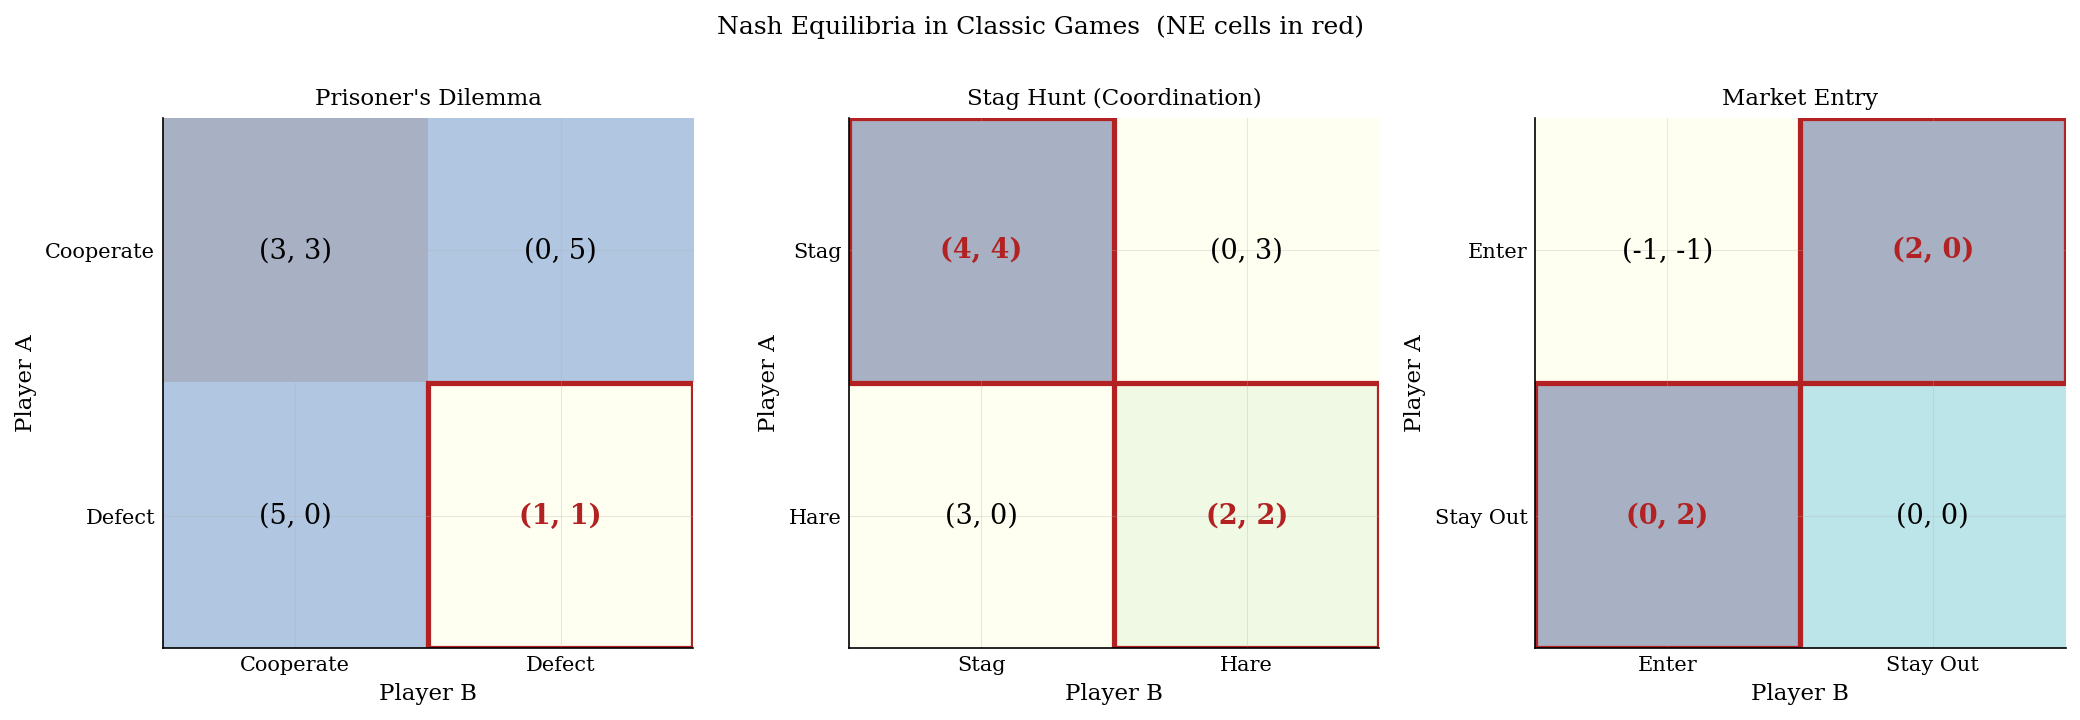

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, game in zip(axes, games):
    A, B = game['A'], game['B']
    ne = find_pure_nash(A, B)
    strats = game['strategies']
    m, n = A.shape

    bg = (A + B).astype(float)
    ax.imshow(bg, cmap='YlGnBu', alpha=0.35, aspect='equal',
              extent=(-0.5, n - 0.5, m - 0.5, -0.5))

    for i in range(m):
        for j in range(n):
            label = f"({A[i, j]}, {B[i, j]})"
            is_ne = (i, j) in ne
            ax.text(j, i, label, ha='center', va='center', fontsize=13,
                    fontweight='bold' if is_ne else 'normal',
                    color='#B22222' if is_ne else 'black')
            if is_ne:
                rect = Rectangle((j - 0.5, i - 0.5), 1, 1, linewidth=2.5,
                                 edgecolor='#B22222', facecolor='none')
                ax.add_patch(rect)

    ax.set_xticks(range(n))
    ax.set_xticklabels(strats, fontsize=10)
    ax.set_yticks(range(m))
    ax.set_yticklabels(strats, fontsize=10)
    ax.set_xlabel('Player B')
    ax.set_ylabel('Player A')
    ax.set_title(game['title'], fontsize=11)
    ax.tick_params(length=0)

fig.suptitle('Nash Equilibria in Classic Games  (NE cells in red)',
             fontsize=12, y=1.03)
fig.tight_layout()
save_fig(fig, '05_game_theory', 'nash_equilibria_heatmaps')
plt.show()

## Section 2 — Auction Theory

In symmetric first-price sealed-bid examples with i.i.d. $U[0,1]$ values, bidders optimally shade below $v$, while the second-price (Vickrey) auction makes truthful bidding a dominant strategy. See [auction_theory.md](../theory/05_game_theory/auction_theory.md).


In [5]:
def simulate_auction(
    n_bidders: int,
    n_auctions: int,
    auction_type: str,
    rng: np.random.Generator,
) -> dict[str, np.ndarray]:
    """Simulate sealed-bid auctions with optimal bidding strategies.

    Parameters
    ----------
    n_bidders : int
        Number of bidders in each auction.
    n_auctions : int
        Number of independent auctions to simulate.
    auction_type : str
        ``'first_price'`` or ``'second_price'``.
    rng : np.random.Generator
        Random number generator for reproducibility.

    Returns
    -------
    dict with keys
        ``'revenues'``         — price paid per auction,
        ``'winner_values'``    — true value of the auction winner,
        ``'winner_bids'``      — bid submitted by the winner,
        ``'winner_surpluses'`` — winner's value minus price paid.

    Notes
    -----
    Bidders draw private values from U[0, 1].
    First-price: optimal bid = v * (n-1)/n  (bid shading).
    Second-price: optimal bid = v  (truthful, dominant strategy).
    """
    values = rng.uniform(0.0, 1.0, size=(n_auctions, n_bidders))

    if auction_type == 'first_price':
        bids = values * (n_bidders - 1) / n_bidders
    elif auction_type == 'second_price':
        bids = values.copy()
    else:
        raise ValueError(f"Unknown auction_type: {auction_type!r}")

    winner_idx = np.argmax(bids, axis=1)
    rows = np.arange(n_auctions)
    winner_values = values[rows, winner_idx]
    winner_bids = bids[rows, winner_idx]

    if auction_type == 'first_price':
        revenues = winner_bids.copy()
    else:
        sorted_bids = np.sort(bids, axis=1)
        revenues = sorted_bids[:, -2]

    return {
        'revenues': revenues,
        'winner_values': winner_values,
        'winner_bids': winner_bids,
        'winner_surpluses': winner_values - revenues,
    }

In [6]:
rng = np.random.default_rng(42)
n_sims = 10_000
n_bidders = 5
v = 0.8

strategies: dict[str, float] = {
    'Truthful (b = v)':           v,
    'Optimal shading (b = 0.64)': v * (n_bidders - 1) / n_bidders,
    'Under-shading (b = 0.72)':   v * 0.9,
    'Over-shading (b = 0.48)':    v * 0.6,
}

opponent_values = rng.uniform(0.0, 1.0, size=(n_sims, n_bidders - 1))
opponent_bids = opponent_values * (n_bidders - 1) / n_bidders

print(f"First-price auction  |  {n_bidders} bidders  |  your value v = {v}")
print(f"Opponents bid optimally: b = v * {(n_bidders - 1) / n_bidders:.2f}")
print()
print(f"{'Strategy':<30s}  {'Bid':>5s}  {'Win %':>6s}  {'E[payoff]':>10s}")
print('-' * 58)

best_name, best_payoff = '', -np.inf
for name, bid in strategies.items():
    wins = bid > np.max(opponent_bids, axis=1)
    payoffs = np.where(wins, v - bid, 0.0)
    expected = float(np.mean(payoffs))
    win_pct = float(np.mean(wins)) * 100
    print(f"{name:<30s}  {bid:5.2f}  {win_pct:5.1f}%  {expected:10.4f}")
    if expected > best_payoff:
        best_payoff = expected
        best_name = name

print(f"\nBest strategy: {best_name}  (E[payoff] = {best_payoff:.4f})")

First-price auction  |  5 bidders  |  your value v = 0.8
Opponents bid optimally: b = v * 0.80

Strategy                          Bid   Win %   E[payoff]
----------------------------------------------------------
Truthful (b = v)                 0.80  100.0%      0.0000
Optimal shading (b = 0.64)       0.64   40.9%      0.0655
Under-shading (b = 0.72)         0.72   65.6%      0.0525
Over-shading (b = 0.48)          0.48   12.4%      0.0397

Best strategy: Optimal shading (b = 0.64)  (E[payoff] = 0.0655)


Saved → plots/05_game_theory/revenue_equivalence.[pdf|png]


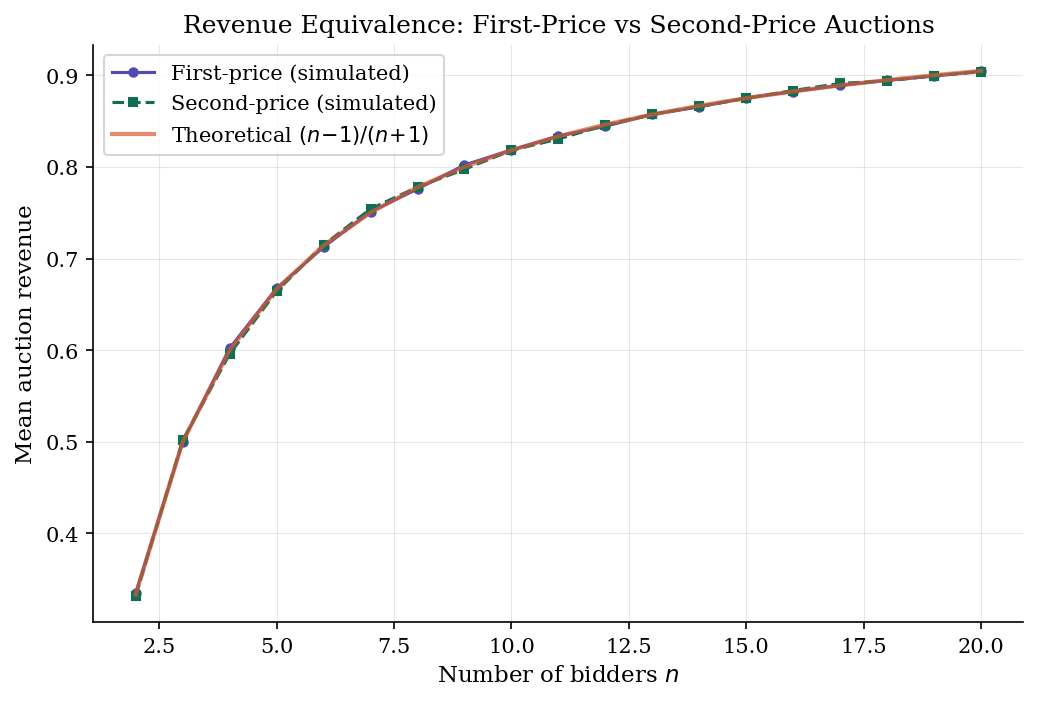

In [7]:
n_auctions = 5_000
bidder_range = np.arange(2, 21)

mean_rev_fp = np.empty(len(bidder_range))
mean_rev_sp = np.empty(len(bidder_range))

for idx, n in enumerate(bidder_range):
    seed_rng = np.random.default_rng(idx)
    fp = simulate_auction(n, n_auctions, 'first_price', seed_rng)
    seed_rng = np.random.default_rng(idx + 1000)
    sp = simulate_auction(n, n_auctions, 'second_price', seed_rng)
    mean_rev_fp[idx] = np.mean(fp['revenues'])
    mean_rev_sp[idx] = np.mean(sp['revenues'])

theoretical = (bidder_range - 1) / (bidder_range + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(bidder_range, mean_rev_fp, 'o-', color=COLORS[0], lw=1.5, ms=4,
        label='First-price (simulated)')
ax.plot(bidder_range, mean_rev_sp, 's--', color=COLORS[1], lw=1.5, ms=4,
        label='Second-price (simulated)')
ax.plot(bidder_range, theoretical, '-', color=COLORS[2], lw=2, alpha=0.7,
        label=r'Theoretical $(n\!-\!1)/(n\!+\!1)$')
ax.set_xlabel(r'Number of bidders $n$')
ax.set_ylabel('Mean auction revenue')
ax.set_title('Revenue Equivalence: First-Price vs Second-Price Auctions')
ax.legend()
save_fig(fig, '05_game_theory', 'revenue_equivalence')
plt.show()

## Section 3 — Repeated Games

Discounted payoffs $\sum_{t=0}^{\infty} \delta^t u_i(a^t)$ make future punishment matter, so outcomes such as permanent cooperation can be equilibrium behaviour even when the one-shot game has a unique Nash equilibrium in dominant strategies. The code uses the symmetric Prisoner's Dilemma from [repeated_games.md](../theory/05_game_theory/repeated_games.md), compares grim trigger and tit-for-tat to benchmark rules, and plots the critical discount factor at which a one-shot deviation from mutual cooperation stops paying off.


Saved → plots/05_game_theory/repeated_games_pd.[pdf|png]


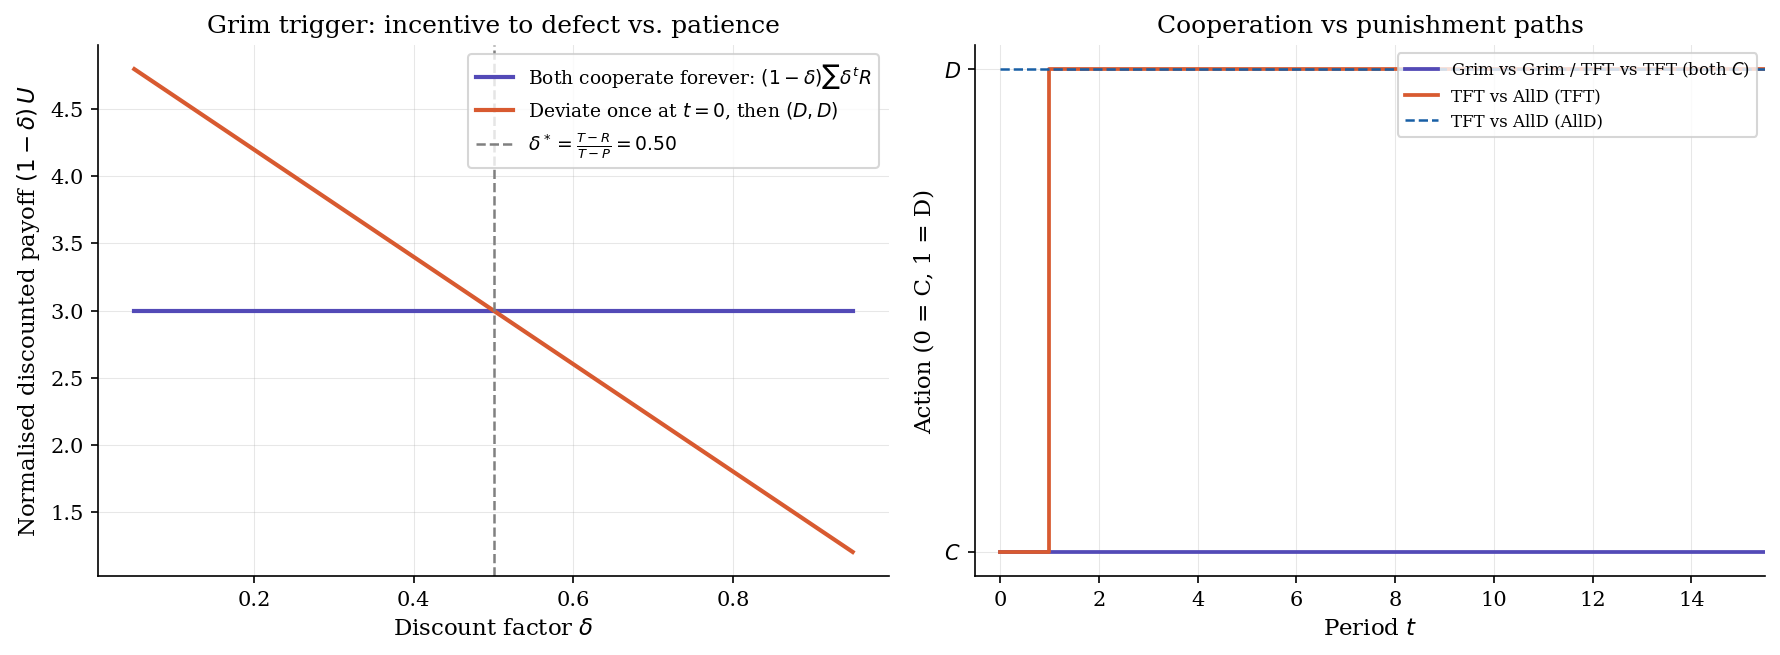

Average discounted payoffs (player 1), delta = 0.92
  Grim vs Grim    AD(P1) = 3.0000
  TFT vs TFT      AD(P1) = 3.0000
  TFT vs AllD     AD(P1) = 0.9200
  AllD vs AllD    AD(P1) = 1.0000


In [8]:
# Symmetric Prisoner's Dilemma: C = 0 (cooperate), D = 1 (defect)
# Payoffs (row player, column player):  (C,C)=(R,R), (C,D)=(S,T), (D,C)=(T,S), (D,D)=(P,P)
R, T, P, S = 3, 5, 1, 0


def pd_payoffs(a1: int, a2: int) -> tuple[int, int]:
    if a1 == 0 and a2 == 0:
        return R, R
    if a1 == 0 and a2 == 1:
        return S, T
    if a1 == 1 and a2 == 0:
        return T, S
    return P, P


def simulate_pd(
    action0,
    action1,
    n_periods: int,
) -> tuple[np.ndarray, np.ndarray, list[tuple[int, int]]]:
    """Return per-period payoffs and full action history."""
    history: list[tuple[int, int]] = []
    u0 = np.empty(n_periods, dtype=int)
    u1 = np.empty(n_periods, dtype=int)
    for t in range(n_periods):
        a0 = action0(history)
        a1 = action1(history)
        p0, p1 = pd_payoffs(a0, a1)
        u0[t], u1[t] = p0, p1
        history.append((a0, a1))
    return u0, u1, history


def discounted_payoff(u: np.ndarray, delta: float) -> float:
    t = np.arange(len(u), dtype=float)
    return float(np.sum((delta ** t) * u))


def average_discounted(u: np.ndarray, delta: float) -> float:
    """Normalised payoff (1-delta) * sum delta^t u_t — equals u if constant stream."""
    if delta >= 1.0 - 1e-12:
        return float(np.mean(u))
    return (1.0 - delta) * discounted_payoff(u, delta)


def grim(_player: int):
    def choose(history: list[tuple[int, int]]) -> int:
        for a1, a2 in history:
            if a1 != 0 or a2 != 0:
                return 1
        return 0

    return choose


def tft(player: int):
    def choose(history: list[tuple[int, int]]) -> int:
        if not history:
            return 0
        a0, a1 = history[-1]
        return a1 if player == 0 else a0

    return choose


def all_c(_history: list[tuple[int, int]]) -> int:
    return 0


def all_d(_history: list[tuple[int, int]]) -> int:
    return 1


# --- Grim trigger: critical discount factor (theory: delta* = (T-R)/(T-P) = 1/2)
deltas = np.linspace(0.05, 0.95, 200)
coop_norm = np.full_like(deltas, R, dtype=float)
dev_norm = (1.0 - deltas) * (T + deltas / (1.0 - deltas))  # = T(1-d) + d = T - (T-1)*d with T=5 -> 5-4d
delta_star = (T - R) / (T - P)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(deltas, coop_norm, color=COLORS[0], linewidth=2, label=r"Both cooperate forever: $(1-\delta)\sum \delta^t R$")
ax1.plot(deltas, dev_norm, color=COLORS[2], linewidth=2, label=r"Deviate once at $t=0$, then $(D,D)$")
ax1.axvline(delta_star, color="grey", linestyle="--", linewidth=1.2, label=rf"$\delta^* = \frac{{T-R}}{{T-P}} = {delta_star:.2f}$")
ax1.set_xlabel(r"Discount factor $\delta$")
ax1.set_ylabel(r"Normalised discounted payoff $(1-\delta)\,U$")
ax1.set_title("Grim trigger: incentive to defect vs. patience")
ax1.legend(loc="best", fontsize=9)

# --- Strategy paths (finite horizon; discounting used in summary print below)
delta_sim = 0.92
n_rounds = 40
pairs = [
    ("Grim vs Grim", grim(0), grim(1)),
    ("TFT vs TFT", tft(0), tft(1)),
    ("TFT vs AllD", tft(0), all_d),
    ("AllD vs AllD", all_d, all_d),
]

_, _, h_gg = simulate_pd(grim(0), grim(1), n_rounds)
_, _, h_td = simulate_pd(tft(0), all_d, n_rounds)

t_gg = np.arange(len(h_gg) + 1)
ax2.step(
    t_gg[:-1],
    [a for a, _ in h_gg],
    where="post",
    color=COLORS[0],
    linewidth=1.8,
    label="Grim vs Grim / TFT vs TFT (both $C$)",
)

t_td = np.arange(len(h_td) + 1)
ax2.step(t_td[:-1], [a for a, _ in h_td], where="post", color=COLORS[2], linewidth=1.8, label="TFT vs AllD (TFT)")
ax2.step(t_td[:-1], [b for _, b in h_td], where="post", color=COLORS[3], linewidth=1.2, linestyle="--", label="TFT vs AllD (AllD)")

ax2.set_xlabel("Period $t$")
ax2.set_ylabel("Action (0 = C, 1 = D)")
ax2.set_title("Cooperation vs punishment paths")
ax2.set_yticks([0, 1])
ax2.set_yticklabels([r"$C$", r"$D$"])
ax2.legend(loc="upper right", fontsize=8)
ax2.set_xlim(-0.5, 15.5)

fig.tight_layout()
save_fig(fig, "05_game_theory", "repeated_games_pd")
plt.show()

# Normalised payoffs for the same scenarios (illustrative)
print("Average discounted payoffs (player 1), delta =", delta_sim)
for label, f0, f1 in pairs:
    u0, _, _ = simulate_pd(f0, f1, 500)
    v = average_discounted(u0, delta_sim)
    print(f"  {label:14s}  AD(P1) = {v:.4f}")


## Prosperity 4 Takeaways

Treat rival bots as optimisers and identify the auction rule before you bid, because Vickrey incentives differ sharply from first-price shading. More aggressive market makers compress everyone’s edge, so adapt between market making, directional, and stat-arb styles as competition changes.
